# Smart Device Market Analysis (EDA)

## Project Overview
This project performs Exploratory Data Analysis (EDA) on a dataset of wearable devices such as smartwatches and fitness bands.

The goal is to analyze pricing trends, brand positioning, product features, and customer ratings using Python.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r'Fitness_trackers.csv')

In [17]:
df.head()

,Brand Name,Device Type,Model Name,Color,Selling Price,Original Price,Display,Rating (Out of 5),Strap Material,Average Battery Life (in days),Reviews
0,Xiaomi,FitnessBand,Smart Band 5,Black,"2,499","2,999",AMOLED Display,4.1,Thermoplastic polyurethane,14,NaN
1,Xiaomi,FitnessBand,Smart Band 4,Black,"2,099","2,499",AMOLED Display,4.2,Thermoplastic polyurethane,14,NaN
2,Xiaomi,FitnessBand,HMSH01GE,Black,"1,722","2,099",LCD Display,3.5,Leather,14,NaN
3,Xiaomi,FitnessBand,Smart Band 5,Black,"2,469","2,999",AMOLED Display,4.1,Thermoplastic polyurethane,14,NaN
4,Xiaomi,FitnessBand,Band 3,Black,"1,799","2,199",OLED Display,4.3,Plastic,7,NaN


In [18]:
df[['Rating (Out of 5)','Reviews']] = df[['Rating (Out of 5)','Reviews']].fillna(0)

In [19]:
df.isna().sum()

Brand Name                        0
Device Type                       0
Model Name                        0
Color                             0
Selling Price                     0
Original Price                    0
Display                           0
Rating (Out of 5)                 0
Strap Material                    0
Average Battery Life (in days)    0
Reviews                           0
dtype: int64

In [20]:
df.head()

,Brand Name,Device Type,Model Name,Color,Selling Price,Original Price,Display,Rating (Out of 5),Strap Material,Average Battery Life (in days),Reviews
0,Xiaomi,FitnessBand,Smart Band 5,Black,"2,499","2,999",AMOLED Display,4.1,Thermoplastic polyurethane,14,0
1,Xiaomi,FitnessBand,Smart Band 4,Black,"2,099","2,499",AMOLED Display,4.2,Thermoplastic polyurethane,14,0
2,Xiaomi,FitnessBand,HMSH01GE,Black,"1,722","2,099",LCD Display,3.5,Leather,14,0
3,Xiaomi,FitnessBand,Smart Band 5,Black,"2,469","2,999",AMOLED Display,4.1,Thermoplastic polyurethane,14,0
4,Xiaomi,FitnessBand,Band 3,Black,"1,799","2,199",OLED Display,4.3,Plastic,7,0


In [21]:
#Brand_Name = df.groupby('Brand Name')['Device Type']
#for i in Brand_Name:
    #print(i)

In [22]:
df.columns

Index(['Brand Name', 'Device Type', 'Model Name', 'Color', 'Selling Price',
       'Original Price', 'Display', 'Rating (Out of 5)', 'Strap Material',
       'Average Battery Life (in days)', 'Reviews'],
      dtype='object')

In [23]:
df.dtypes

Brand Name                         object
Device Type                        object
Model Name                         object
Color                              object
Selling Price                      object
Original Price                     object
Display                            object
Rating (Out of 5)                 float64
Strap Material                     object
Average Battery Life (in days)      int64
Reviews                            object
dtype: object

In [24]:
df[['Selling Price','Original Price']] = df[['Selling Price','Original Price']].astype(str).replace(r'[^\d]','',regex=True).astype(int)

In [25]:
df.dtypes

Brand Name                         object
Device Type                        object
Model Name                         object
Color                              object
Selling Price                       int64
Original Price                      int64
Display                            object
Rating (Out of 5)                 float64
Strap Material                     object
Average Battery Life (in days)      int64
Reviews                            object
dtype: object

In [26]:
df.describe()

,Selling Price,Original Price,Rating (Out of 5),Average Battery Life (in days)
count,565.000000,565.000000,565.000000,565.000000
mean,22110.373451,25365.361062,3.848142,9.026549
std,19914.926066,20384.028759,1.269186,7.868670
min,1195.000000,1599.000000,0.000000,1.000000
25%,8990.000000,12999.000000,3.900000,2.000000
50%,15995.000000,19995.000000,4.200000,7.000000
75%,29900.000000,32900.000000,4.500000,14.000000
max,122090.000000,122090.000000,5.000000,45.000000


In [27]:
df[['Color','Model Name','Brand Name','Display','Strap Material']].value_counts()

Color       Model Name                                      Brand Name  Display              Strap Material 
Black       Amazfit Verge                                   huami       AMOLED Display       Silicone           4
            Series 7 GPS + Cellular, 45 mm Stainless Steel  APPLE       OLED Retina Display  Stainless Steel    2
            Amazfit GTR 47                                  huami       AMOLED Display       Silicone           2
Black       Charge 2                                        FitBit      PMOLED Display       Silicone           2
Grey        Galaxy Active 2                                 SAMSUNG     AMOLED Display       Silicone           2
                                                                                                               ..
Black       band 4 running                                  Honor       AMOLED Display       Plastic            1
            Z1                                              Honor       OLED Display         

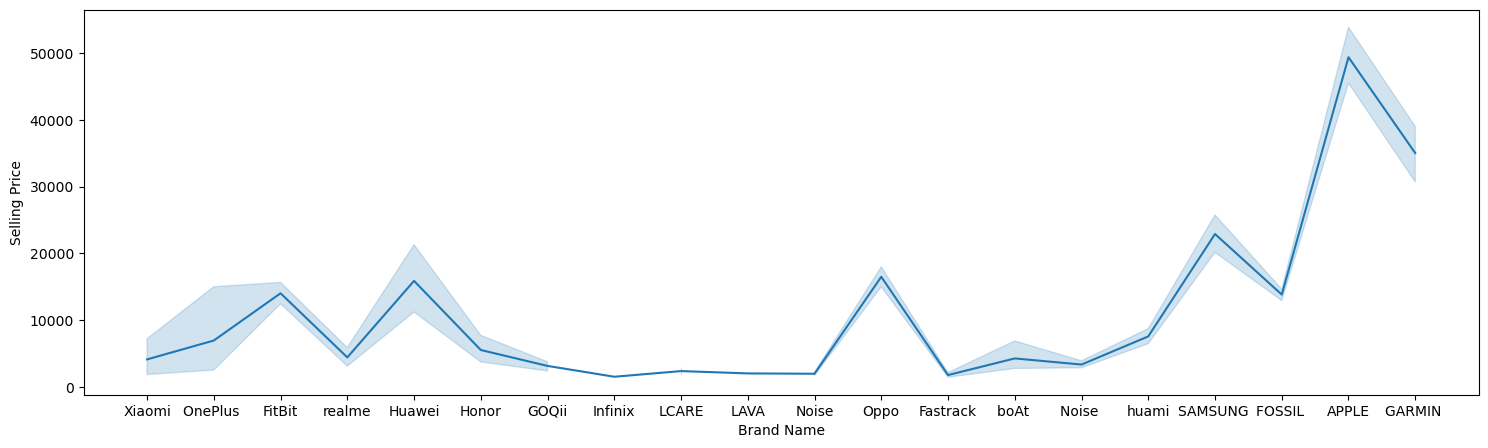

In [72]:
import seaborn as sns

plt.figure(figsize=(18,5))
sns.lineplot(data=df, x='Brand Name', y='Selling Price')
plt.savefig("images/price_distribution.png")

In [29]:
df[df['Selling Price'] == df['Selling Price'].max()][['Brand Name', 'Model Name','Selling Price']]

,Brand Name,Model Name,Selling Price
430,APPLE,Series 3 GPS + Cellular- 42 mm Gray Ceramic Case,122090
435,APPLE,Series 3 GPS + Cellular- 42 mm White Ceramic Case,122090


In [30]:
df['Diffrence Price'] = df['Original Price'] - df['Selling Price']

In [31]:
df[df['Diffrence Price'] == df['Diffrence Price'].max()][['Brand Name','Model Name', 'Color', 'Display','Original Price', 'Selling Price' ]]

,Brand Name,Model Name,Color,Display,Original Price,Selling Price
20,FitBit,FB413LVLV,Lilac,AMOLED Display,38500,8807


**Discounting Trends: What is the average discount percentage across different brands?
Is there a brand that consistently offers the deepest discounts?**

In [32]:
df['Discount %'] = (df['Diffrence Price'] / df['Original Price']) * 100

In [33]:
average_discount = df.groupby('Brand Name')['Discount %'].mean().sort_values(ascending=False)
average_discount

Brand Name
Infinix     50.016672
Noise       45.957228
LAVA        42.869391
boAt        41.105362
LCARE       38.321266
realme      31.509285
huami       31.407211
Huawei      28.384470
Oppo        26.511855
Fastrack    26.420207
Honor       23.775218
Noise       22.008804
FitBit      18.622856
Xiaomi      17.643588
FOSSIL      17.590179
SAMSUNG     14.976566
OnePlus     13.329296
GARMIN      12.946804
APPLE        3.990712
GOQii        0.000000
Name: Discount %, dtype: float64

In [34]:
max_avarageDescounted_BrandName = average_discount.idxmax()
max_avarageDescounted_value = average_discount.max()

print(f'Brand with deepest discount: {max_avarageDescounted_BrandName}')
print(f'Average discount: {max_avarageDescounted_value}')

Brand with deepest discount: Infinix
Average discount: 50.01667222407469


**Price vs. Rating: Is there a correlation between the Selling Price and the Rating?
Do more expensive devices actually perform better in the eyes of the consumer?**

In [35]:
correlation = df['Selling Price'].corr(df['Rating (Out of 5)'])
correlation

np.float64(-0.2510567433142824)

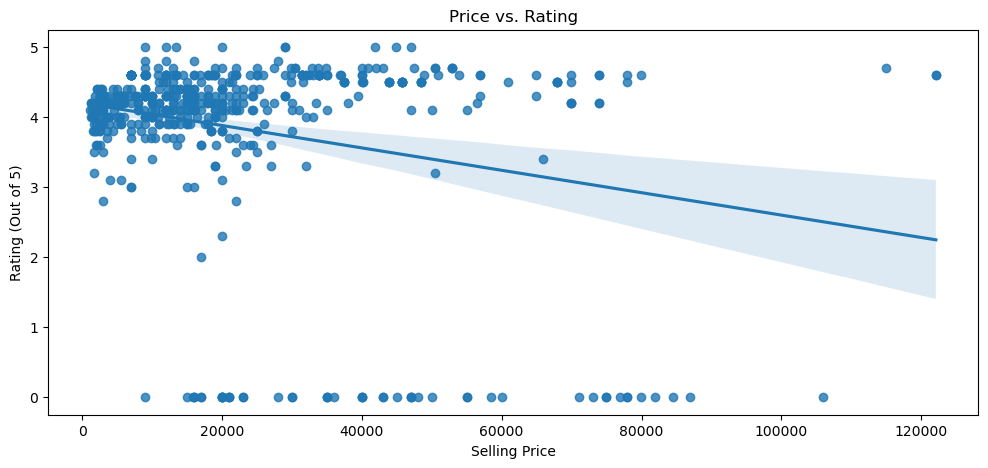

In [71]:
plt.figure(figsize=(12,5))
sns.regplot(data=df, x= 'Selling Price', y='Rating (Out of 5)')
plt.title("Price vs. Rating")
plt.savefig("images/PriceVsRating.png")
plt.show()


**The Luxury Segment: Which Brand Name has the highest Original Price on average, and how does their Device Type distribution look?**


In [37]:
average_org_price = df.groupby('Brand Name')['Original Price'].mean()
LuxurySegment = average_org_price.idxmax()
print(f'The highest Original Price on average: {LuxurySegment}')

The highest Original Price on average: APPLE


In [38]:
Device_distribution = df[df['Brand Name'] == LuxurySegment]['Device Type'].value_counts()
Device_distribution

Device Type
Smartwatch    86
Name: count, dtype: int64

2. Performance & Features

**Battery Life Distribution: What is the most common Average Battery Life? Are there any extreme outliers (e.g., a watch that lasts 30 days vs. 1 day)?**

In [39]:
Days = df['Average Battery Life (in days)'].mode()
print(f'{Days} Days')

0    14
Name: Average Battery Life (in days), dtype: int64 Days


**Battery Life Distribution (Histogram)**

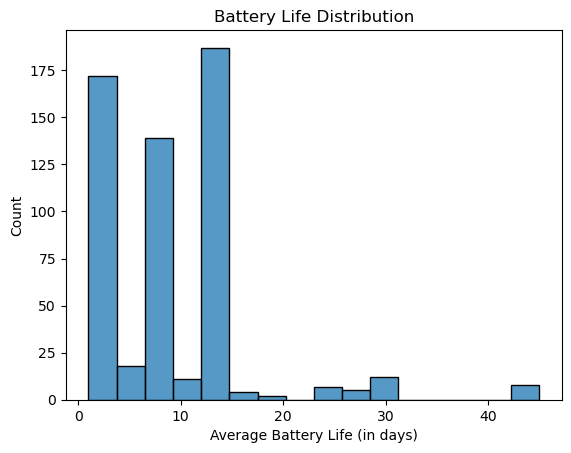

In [70]:
sns.histplot(data =df, x='Average Battery Life (in days)')
plt.title("Battery Life Distribution")
plt.savefig("images/Battery Life Distribution.png")
plt.show()

**Detect Extreme Outliers**

In [41]:
#IQR

Q1 = df['Average Battery Life (in days)'].quantile(0.25)
Q3 = df['Average Battery Life (in days)'].quantile(0.75)

IQR = Q3 - Q1

lowerFence = Q1-1.5*(IQR)
upperFence = Q3+1.5*(IQR)

print(f'Q1 : {Q1} \nQ3 : {Q3} \nIQR : {IQR} \nLower Fence : {lowerFence} \nUpper Fence {upperFence}')

Outliers = df[(df['Average Battery Life (in days)'] < lowerFence) | (df['Average Battery Life (in days)'] > upperFence)][['Model Name', 'Device Type', 'Average Battery Life (in days)']]
Outliers

Q1 : 2.0 
Q3 : 14.0 
IQR : 12.0 
Lower Fence : -16.0 
Upper Fence 32.0


,Model Name,Device Type,Average Battery Life (in days)
455,Fenix 6 Pro Solar,Smartwatch,45
456,Fenix 6X,Smartwatch,45
463,Fenix 6X Solar,Smartwatch,45
464,Fenix 6,Smartwatch,45
481,Fenix 6X,Smartwatch,45
491,Fenix 6 Sapphire Titanium,Smartwatch,45
499,Fenix 6S,Smartwatch,45
504,Fenix 6 Pro Solar,Smartwatch,45


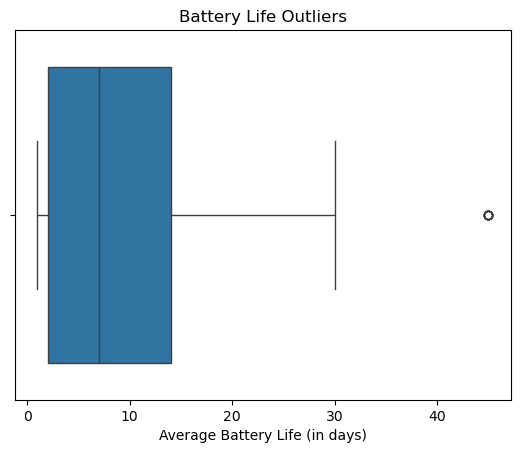

In [69]:
sns.boxplot(data=df, x='Average Battery Life (in days)')
plt.title("Battery Life Outliers")
plt.savefig("images/Battery Life Outliears.png")
plt.show()

**Strap Material Preferences: Does the Strap Material influence the Rating? For example, do users prefer "Leather" over "Silicone" for higher-priced models?**

In [43]:
average_StrapMaterialRating = df.groupby('Strap Material')['Rating (Out of 5)'].mean().sort_values(ascending=False)
average_StrapMaterialRating

Strap Material
Aluminium                     4.573684
Elastomer                     4.300000
Stainless Steel               4.242268
Plastic                       4.218750
Fabric                        4.100000
Thermoplastic polyurethane    4.057576
Rubber                        3.927273
Leather                       3.803390
Silicone                      3.475862
leather                       3.000000
Nylon                         2.166667
Leather                       0.000000
Name: Rating (Out of 5), dtype: float64

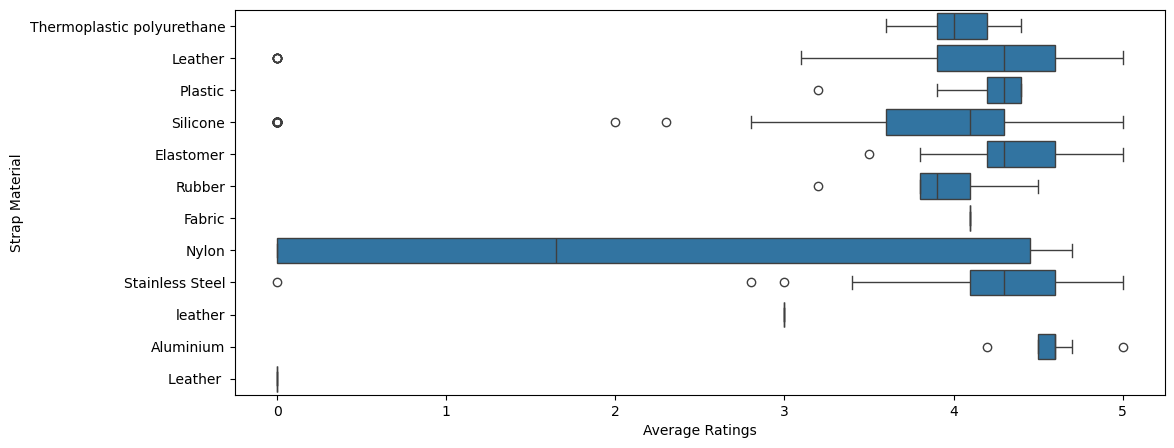

In [68]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='Rating (Out of 5)', y= 'Strap Material')
plt.xlabel("Average Ratings")
plt.ylabel("Strap Material")
plt.savefig("images/Strap Material Preferences.png")
plt.show()

**Display Impact: How does the Display type (e.g., AMOLED vs. LCD) affect both the Selling Price and the Average Battery Life?**

In [45]:
DisplayAnalysis = df.groupby('Display')[['Selling Price','Average Battery Life (in days)']].mean()
DisplayAnalysis

,Selling Price,Average Battery Life (in days)
Display,,
AMOLED Display,17604.563380,10.563380
LCD Display,13056.400000,7.800000
LED Display,23065.607143,12.785714
OLED Display,20863.511628,11.976744
OLED Retina Display,49413.837209,1.000000
PMOLED Display,7983.200000,7.150000
TFT-LCD Display,2260.846154,7.076923


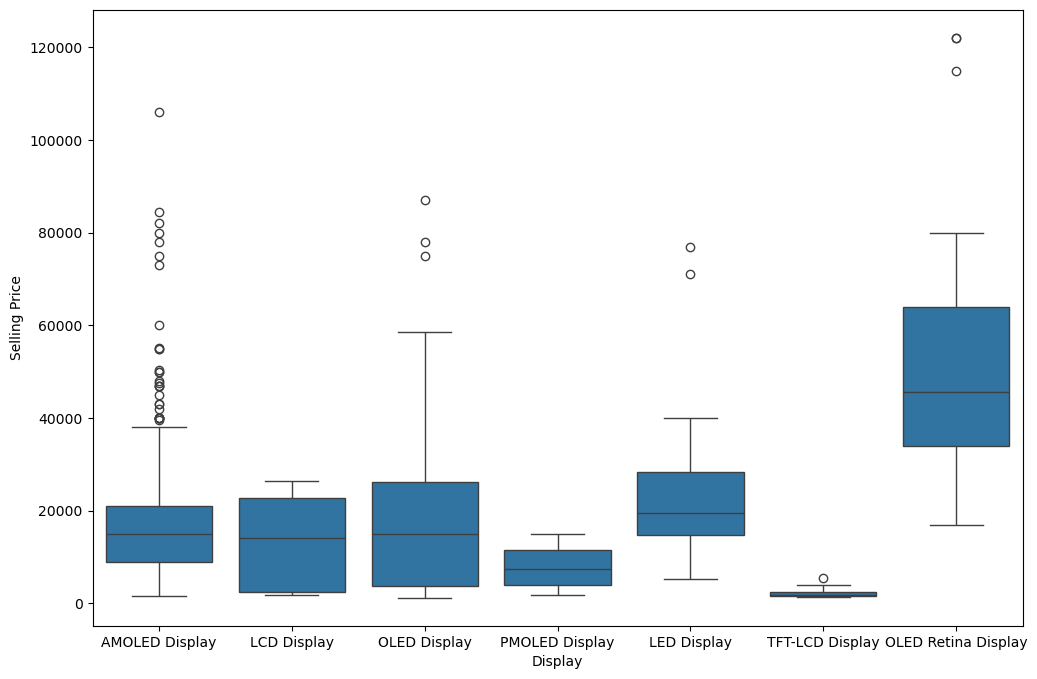

In [67]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df, x='Display', y='Selling Price')
plt.savefig("images/Display_Impact.png")
plt.show()

**3. Brand & Market Insights**

Brand Popularity: Which brand has the highest number of Reviews?
Does high volume always correlate with a high Rating?

In [47]:
BrandPopularity = df.groupby('Brand Name')['Rating (Out of 5)'].sum().sort_values(ascending=False)
BrandPopularity

Brand Name
FOSSIL      564.5
APPLE       390.9
FitBit      213.5
GARMIN      204.3
SAMSUNG     203.0
huami       149.5
Huawei      108.2
Honor        83.9
Noise        69.0
realme       49.7
Xiaomi       41.7
Fastrack     24.1
boAt         15.6
GOQii        13.4
OnePlus      12.9
Oppo          7.8
Noise         7.5
LCARE         7.3
Infinix       3.8
LAVA          3.6
Name: Rating (Out of 5), dtype: float64

**Color Variety: Which Color is the most common across all devices?
Does a specific color (like "Gold" or "Black") command a higher Selling Price?**

In [48]:
df.columns

Index(['Brand Name', 'Device Type', 'Model Name', 'Color', 'Selling Price',
       'Original Price', 'Display', 'Rating (Out of 5)', 'Strap Material',
       'Average Battery Life (in days)', 'Reviews', 'Diffrence Price',
       'Discount %'],
      dtype='object')

In [53]:
ColorVariety = df.groupby('Device Type')['Color'].value_counts().drop_duplicates()
ColorVariety

Color
38    1
Name: count, dtype: int64

In [55]:
ColorPrice = df.groupby('Color')['Selling Price'].mean().sort_values(ascending=False)
ColorPrice

Color
Cloud                         114900.0
Bluw, White                    86990.0
Black, Orange, Red             79990.0
Black, Red, Orange             76990.0
Black, Grey                    74865.0
                                ...   
Charcoal Black, Beige Gold      2499.0
Olive Green                     2199.0
Pink, Black                     2199.0
Black, Blue, Red                1999.0
Orange, Red, Black              1595.0
Name: Selling Price, Length: 146, dtype: float64

**Device Type Breakdown: What is the ratio of Smartwatches to Fitness Bands (or other device types) in this dataset?**

In [62]:
DeviceRatio = df['Device Type'].value_counts(normalize=True)
DeviceRatio

Device Type
Smartwatch     0.867257
FitnessBand    0.132743
Name: proportion, dtype: float64

**Price Skewness: Is the Selling Price normally distributed, or is it heavily skewed toward budget-friendly devices?**

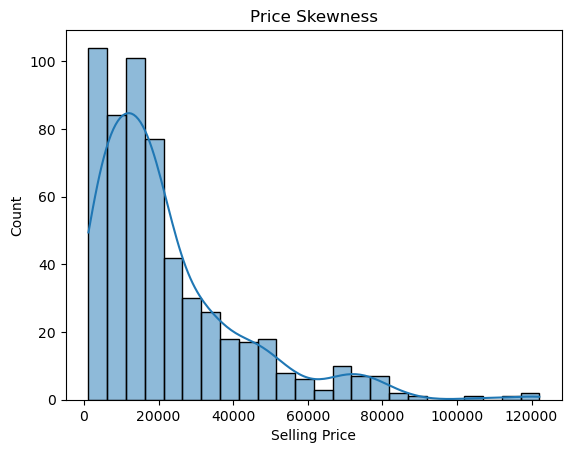

In [66]:
sns.histplot(data=df['Selling Price'], kde=True)
plt.title("Price Skewness")
plt.savefig("images/Price_Skweness.png")
plt.show()